In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
# RDKit分子绘图库
from rdkit import Chem
from rdkit.Chem import Draw
# Jupyter图片展示工具
from IPython.display import Image, display

MGF中共有 194 个带SMILES的化合物
分段阈值 RI<700用|ΔRI|≤111, RI≥700用|ΔRI|/RI≤17%
  无筛选:   Top1=94/134(70.1%), Top3=118/134(88.1%), Top5=125/134(93.3%), Top10=129/134(96.3%)
  RI筛选:   Top1=99/134(73.9%), Top3=120/134(89.6%), Top5=129/134(96.3%), Top10=129/134(96.3%)
  变化: T1+5, T3+2, T5+4, T10+0


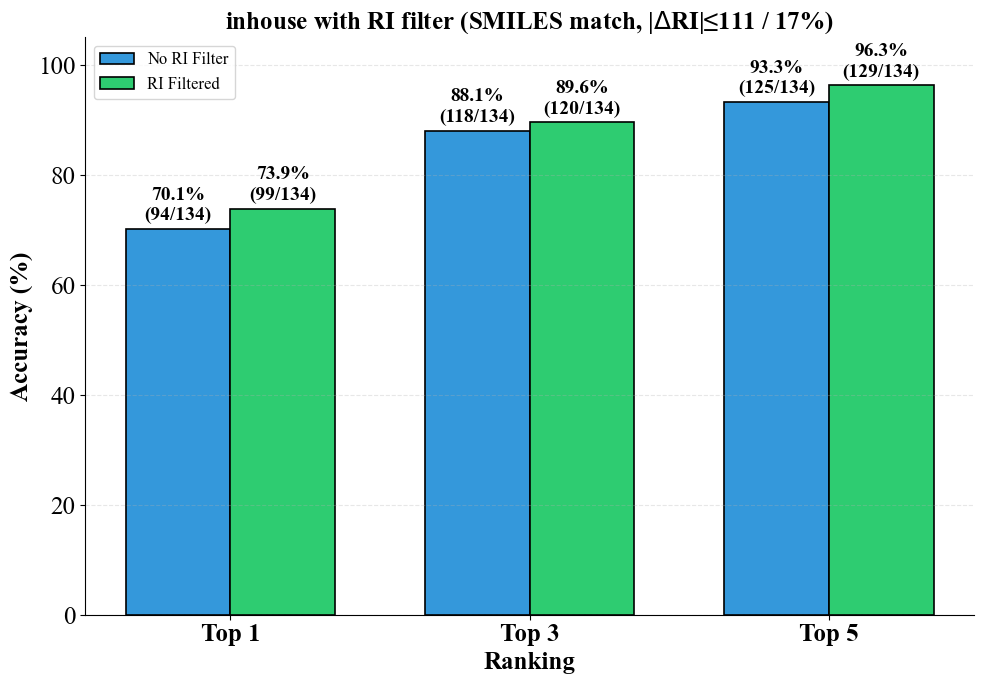

柱状图已保存到: /Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_smiles_RI_filter_top135.png


In [2]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

def parse_mgf_for_reference(mgf_path):
    reference = {}
    current = None
    with open(mgf_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line == 'BEGIN IONS':
                current = {'identifier': None, 'smiles': None, 'inchikey': None, 'ri': None}
            elif line == 'END IONS':
                if current and current['identifier'] and current['smiles']:
                    key = current['identifier']
                    reference[key] = {'smiles': current['smiles'], 'inchikey': current['inchikey'], 'ri': current['ri']}
                current = None
            elif current is not None:
                if line.startswith('IDENTIFIER='):
                    current['identifier'] = line.split('=', 1)[1].strip()
                elif line.startswith('SMILES='):
                    current['smiles'] = line.split('=', 1)[1].strip()
                elif line.startswith('INCHIKEY='):
                    current['inchikey'] = line.split('=', 1)[1].strip()
                elif line.startswith('RI='):
                    try:
                        current['ri'] = float(line.split('=', 1)[1].strip())
                    except:
                        pass
    return reference

def canonicalize_smiles(smiles):
    if not smiles or pd.isna(smiles) or str(smiles) == 'nan':
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

def find_first_correct_pos_by_smiles(df, ref_canonical_smiles):
    for pos in range(len(df)):
        if 'CanonicalSMILES' not in df.columns:
            return -1
        c_sm = canonicalize_smiles(str(df.iloc[pos].get('CanonicalSMILES', '')))
        if c_sm and c_sm == ref_canonical_smiles:
            return pos
    return -1

def run_eval(csv_dir, reference, abs_thresh, rel_thresh, ri_boundary):
    csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]
    results_no = []
    results_filtered = []

    for csv_filename in sorted(csv_files):
        identifier = csv_filename.replace('.csv', '')
        if identifier not in reference:
            continue
        ref_info = reference.get(identifier)
        if not ref_info:
            continue
        ref_canonical_smiles = canonicalize_smiles(ref_info.get('smiles'))
        ref_ri = ref_info.get('ri')
        if not ref_canonical_smiles:
            continue

        csv_path = os.path.join(csv_dir, csv_filename)
        try:
            df = pd.read_csv(csv_path)
        except:
            continue
        if 'CanonicalSMILES' not in df.columns or 'Predicted_RI' not in df.columns:
            continue
        df = df.reset_index(drop=True)

        no_pos = find_first_correct_pos_by_smiles(df, ref_canonical_smiles)
        if no_pos == -1:
            # SMILES未匹配到正确注释，直接去除，不计入总数
            continue
        results_no.append({
            'top1': no_pos == 0, 'top3': 0 <= no_pos < 3, 'top5': 0 <= no_pos < 5, 'top10': 0 <= no_pos < 10
        })

        if ref_ri is not None and ref_ri > 0:
            df['RI_diff_abs'] = df['Predicted_RI'].apply(
                lambda x: abs(float(x) - ref_ri) if pd.notna(x) else float('inf')
            )
            df['RI_diff_rel'] = df['RI_diff_abs'] / ref_ri

            # 分段阈值: RI<500用绝对值, RI>=500用相对值
            if ref_ri < ri_boundary:
                df_f = df[df['RI_diff_abs'] <= abs_thresh].copy().reset_index(drop=True)
            else:
                df_f = df[df['RI_diff_rel'] <= rel_thresh].copy().reset_index(drop=True)

            f_pos = find_first_correct_pos_by_smiles(df_f, ref_canonical_smiles)
            results_filtered.append({
                'top1': f_pos == 0, 'top3': 0 <= f_pos < 3, 'top5': 0 <= f_pos < 5, 'top10': 0 <= f_pos < 10
            })
        else:
            results_filtered.append(results_no[-1])

    total = len(results_no)
    n1 = sum(1 for r in results_no if r['top1'])
    n3 = sum(1 for r in results_no if r['top3'])
    n5 = sum(1 for r in results_no if r['top5'])
    n10 = sum(1 for r in results_no if r['top10'])
    s1 = sum(1 for r in results_filtered if r['top1'])
    s3 = sum(1 for r in results_filtered if r['top3'])
    s5 = sum(1 for r in results_filtered if r['top5'])
    s10 = sum(1 for r in results_filtered if r['top10'])

    return total, (n1, n3, n5, n10), (s1, s3, s5, s10)

def draw_chart(total, no_counts, seg_counts, abs_thresh, rel_thresh, ri_boundary, output_path):
    categories = ['Top 1', 'Top 3', 'Top 5']
    no_rates = [no_counts[0]/total*100, no_counts[1]/total*100, no_counts[2]/total*100]
    seg_rates = [seg_counts[0]/total*100, seg_counts[1]/total*100, seg_counts[2]/total*100]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 7))
    bars1 = ax.bar(x - width/2, no_rates, width,
                   label='No RI Filter', color='#3498db',
                   edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x + width/2, seg_rates, width,
                   label='RI Filtered', color='#2ecc71', edgecolor='black', linewidth=1.2)

    for bar, rate, count in zip(bars1, no_rates, no_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{rate:.1f}%\n({count}/{total})',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    for bar, rate, count in zip(bars2, seg_rates, seg_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{rate:.1f}%\n({count}/{total})',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Ranking', fontsize=18, fontweight='bold')
    ax.set_title(f'inhouse with RI filter (SMILES match, |$\\Delta$RI|≤{abs_thresh} / {rel_thresh*100:.0f}%)',
                 fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=18, fontweight='bold')
    ax.tick_params(labelsize=18)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"柱状图已保存到: {output_path}")

def main():
    mgf_path = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/MassSpecGym_inhouse.mgf'
    csv_dir = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_predicted_Multi'

    reference = parse_mgf_for_reference(mgf_path)
    print(f"MGF中共有 {len(reference)} 个带SMILES的化合物")

    abs_thresh, rel_thresh, ri_boundary = 111, 0.17, 700
    print("=" * 80)
    print(f"分段阈值 RI<{ri_boundary}用|ΔRI|≤{abs_thresh}, RI≥{ri_boundary}用|ΔRI|/RI≤{rel_thresh*100:.0f}%")
    print("=" * 80)
    total, no_c, seg_c = run_eval(csv_dir, reference, abs_thresh, rel_thresh, ri_boundary)
    print(f"  无筛选:   Top1={no_c[0]}/{total}({no_c[0]/total*100:.1f}%), Top3={no_c[1]}/{total}({no_c[1]/total*100:.1f}%), Top5={no_c[2]}/{total}({no_c[2]/total*100:.1f}%), Top10={no_c[3]}/{total}({no_c[3]/total*100:.1f}%)")
    print(f"  RI筛选:   Top1={seg_c[0]}/{total}({seg_c[0]/total*100:.1f}%), Top3={seg_c[1]}/{total}({seg_c[1]/total*100:.1f}%), Top5={seg_c[2]}/{total}({seg_c[2]/total*100:.1f}%), Top10={seg_c[3]}/{total}({seg_c[3]/total*100:.1f}%)")
    print(f"  变化: T1{seg_c[0]-no_c[0]:+d}, T3{seg_c[1]-no_c[1]:+d}, T5{seg_c[2]-no_c[2]:+d}, T10{seg_c[3]-no_c[3]:+d}")
    draw_chart(total, no_c, seg_c, abs_thresh, rel_thresh, ri_boundary,
               '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_smiles_RI_filter_top135.png')

if __name__ == '__main__':
    main()


inhouse RI筛选效果分析 (SMILES匹配, RI<700: |ΔRI|≤111, RI≥700: |ΔRI|/RI≤17%)
SMILES可匹配化合物总数: 134
排名提升化合物总数: 19

全部 134 个化合物详细信息已保存到: /Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_ri_filter_all_cases.csv

Identifier               Ref_RI Threshold     DeepMASS_Rank  Filtered_Rank   Change Status      
----------------------------------------------------------------------------------------------------
MassSpecGymID0000012     1064.0 rel≤17%                   1              1        0 Unchanged   
MassSpecGymID0001414      575.0 abs≤111                  49             22       27 Improved    
MassSpecGymID0002159      878.0 rel≤17%                   1              1        0 Unchanged   
MassSpecGymID0005842     1095.0 rel≤17%                   2              1        1 Improved    
MassSpecGymID0006859      519.0 abs≤111                   1              1        0 Unchanged   
MassSpecGymID0008140      154.0 abs≤111                   1              1        0 Unchanged   
MassSpecG

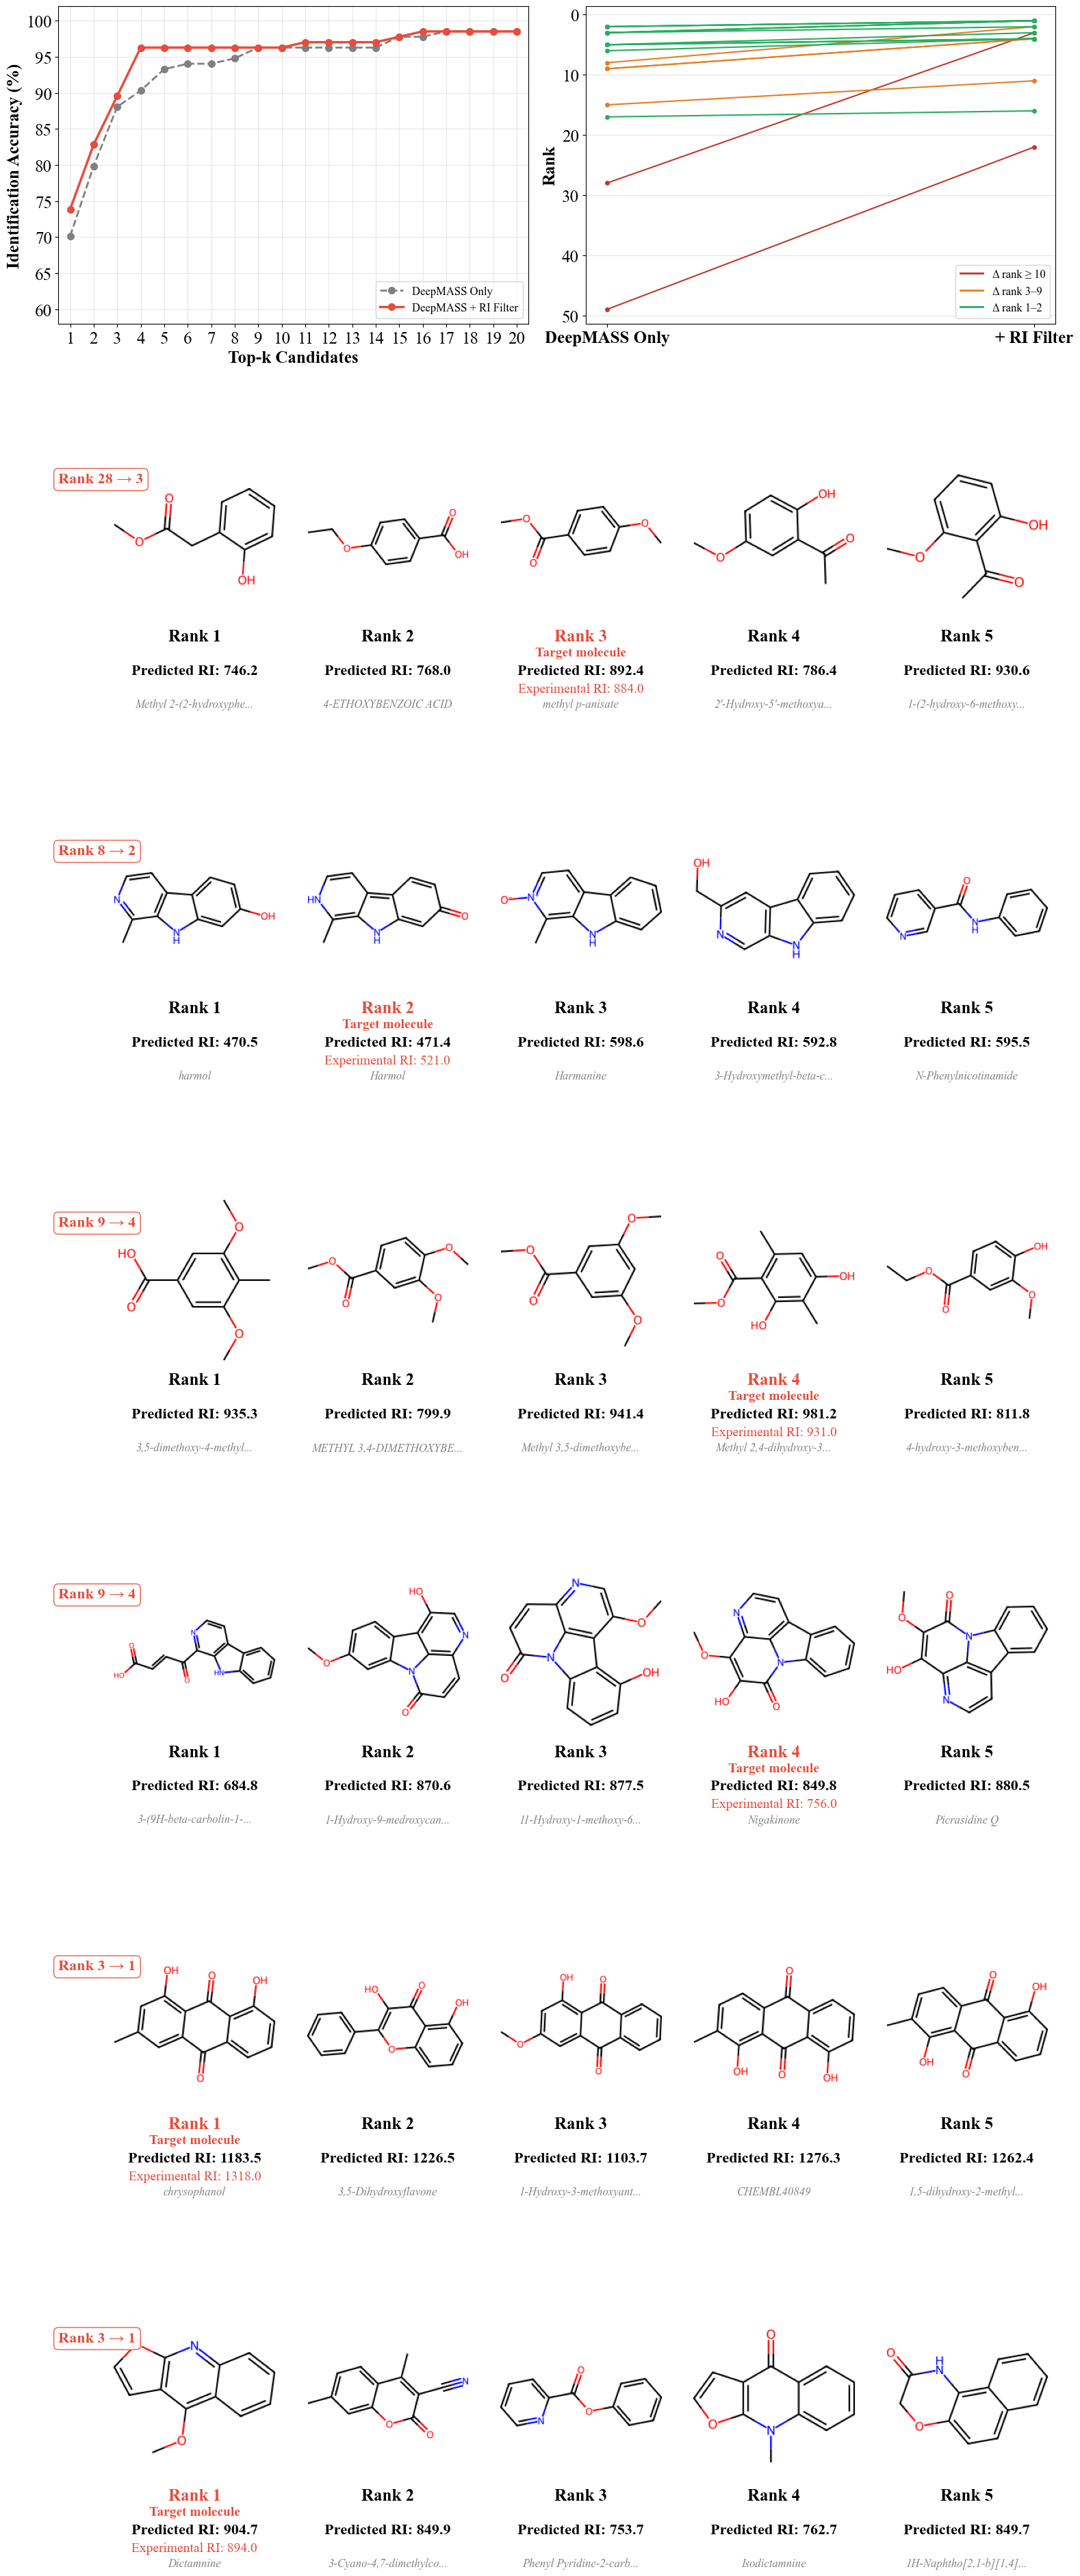


排名提升化合物综合效果图已保存到: /Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_RI_filter_improved_summary.png


In [3]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

def parse_mgf_for_reference(mgf_path):
    reference = {}
    current = None
    with open(mgf_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line == 'BEGIN IONS':
                current = {'identifier': None, 'smiles': None, 'inchikey': None, 'ri': None}
            elif line == 'END IONS':
                if current and current['identifier'] and current['smiles']:
                    reference[current['identifier']] = {
                        'smiles': current['smiles'],
                        'inchikey': current['inchikey'],
                        'ri': current['ri']
                    }
                current = None
            elif current is not None:
                if line.startswith('IDENTIFIER='): current['identifier'] = line.split('=', 1)[1].strip()
                elif line.startswith('SMILES='): current['smiles'] = line.split('=', 1)[1].strip()
                elif line.startswith('INCHIKEY='): current['inchikey'] = line.split('=', 1)[1].strip()
                elif line.startswith('RI='):
                    try: current['ri'] = float(line.split('=', 1)[1].strip())
                    except: pass
    return reference

def canonicalize_smiles(smiles):
    if not smiles or pd.isna(smiles) or str(smiles) == 'nan':
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

def find_first_correct_pos_by_smiles(df, ref_canonical_smiles):
    for pos in range(len(df)):
        if 'CanonicalSMILES' not in df.columns:
            return -1
        c_sm = canonicalize_smiles(str(df.iloc[pos].get('CanonicalSMILES', '')))
        if c_sm and c_sm == ref_canonical_smiles:
            return pos
    return -1

def process_matchable_cases():
    """处理所有134个SMILES可匹配化合物，返回全部案例和提升案例"""
    mgf_path = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/MassSpecGym_inhouse.mgf'
    csv_dir = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_predicted_Multi'
    abs_thresh = 111
    rel_thresh = 0.17
    ri_boundary = 700

    reference = parse_mgf_for_reference(mgf_path)
    all_cases = []
    improved_cases = []
    csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

    for csv_filename in sorted(csv_files):
        identifier = csv_filename.replace('.csv', '')
        if identifier not in reference:
            continue
        ref_info = reference.get(identifier)
        if not ref_info:
            continue
        ref_canonical_smiles = canonicalize_smiles(ref_info.get('smiles'))
        ref_ri = ref_info.get('ri')
        if not ref_canonical_smiles or ref_ri is None or ref_ri <= 0:
            continue

        csv_path = os.path.join(csv_dir, csv_filename)
        try:
            df = pd.read_csv(csv_path)
        except:
            continue
        if 'CanonicalSMILES' not in df.columns or 'Predicted_RI' not in df.columns:
            continue
        df = df.reset_index(drop=True)

        no_pos = find_first_correct_pos_by_smiles(df, ref_canonical_smiles)
        if no_pos == -1:
            continue

        df['RI_diff_abs'] = df['Predicted_RI'].apply(
            lambda x: abs(float(x) - ref_ri) if pd.notna(x) else float('inf')
        )
        df['RI_diff_rel'] = df['RI_diff_abs'] / ref_ri

        if ref_ri < ri_boundary:
            df_f = df[df['RI_diff_abs'] <= abs_thresh].copy().reset_index(drop=True)
            threshold_type = f'abs≤{abs_thresh}'
        else:
            df_f = df[df['RI_diff_rel'] <= rel_thresh].copy().reset_index(drop=True)
            threshold_type = f'rel≤{rel_thresh:.0%}'

        f_pos = find_first_correct_pos_by_smiles(df_f, ref_canonical_smiles)

        pred_ri_correct = df.iloc[no_pos].get('Predicted_RI')
        case = {
            'identifier': identifier,
            'ref_ri': ref_ri,
            'ref_smiles': ref_canonical_smiles,
            'pred_ri_correct': float(pred_ri_correct) if pd.notna(pred_ri_correct) else None,
            'threshold_type': threshold_type,
            'no_pos': no_pos,
            'f_pos': f_pos,
            'no_rank': no_pos + 1,
            'f_rank': f_pos + 1 if f_pos != -1 else '被筛除',
            'improvement': no_pos - f_pos if f_pos >= 0 else None,
        }
        all_cases.append(case)

        if f_pos >= 0 and f_pos < no_pos:
            improved_cases.append(case)

    return all_cases, improved_cases, abs_thresh, rel_thresh, ri_boundary


def get_case_study_data(identifier, ref_smiles, ref_ri, threshold_type, abs_thresh, rel_thresh):
    csv_dir = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_predicted_Multi'
    csv_path = os.path.join(csv_dir, f'{identifier}.csv')
    if not os.path.exists(csv_path):
        return None
    df = pd.read_csv(csv_path)
    df = df.reset_index(drop=True)

    df['RI_diff_abs'] = df['Predicted_RI'].apply(
        lambda x: abs(float(x) - ref_ri) if pd.notna(x) else float('inf')
    )
    df['RI_diff_rel'] = df['RI_diff_abs'] / ref_ri

    if threshold_type.startswith('abs'):
        df_f = df[df['RI_diff_abs'] <= abs_thresh].copy().reset_index(drop=True)
    else:
        df_f = df[df['RI_diff_rel'] <= rel_thresh].copy().reset_index(drop=True)

    correct_pos = find_first_correct_pos_by_smiles(df_f, ref_smiles)
    return df_f, ref_ri, correct_pos


def draw_case_panel(fig, gs_row, label, case, abs_thresh, rel_thresh):
    """绘制单个案例面板（展示筛选后Top 5候选，高亮Target）"""
    ax_outer = fig.add_subplot(gs_row)
    ax_outer.axis('off')
    ax_outer.set_zorder(10)


    case_id = case['identifier']
    case_data = get_case_study_data(
        case_id, case['ref_smiles'], case['ref_ri'],
        case['threshold_type'], abs_thresh, rel_thresh
    )
    if case_data is None:
        return ax_outer

    df_f, ref_ri, correct_pos = case_data
    n_show = min(5, len(df_f))
    inner_gs = gs_row.subgridspec(1, n_show + 1, wspace=0.1, width_ratios=[0.18] + [1.0] * n_show)

    for idx in range(n_show):
        ax_mol = fig.add_subplot(inner_gs[0, idx + 1])
        ax_mol.axis('off')
        # 手动缩小分子子图高度，留出顶部空间给Rank注释（尽量紧凑）
        pos = ax_mol.get_position()
        h = pos.height
        new_y1 = pos.y1 - h * 0.01
        new_y0 = pos.y0
        ax_mol.set_position([pos.x0, new_y0, pos.x1 - pos.x0, new_y1 - new_y0])

        row = df_f.iloc[idx]
        smiles = str(row['CanonicalSMILES'])
        pred_ri = float(row['Predicted_RI'])
        title = str(row['Title']) if 'Title' in row else ''

        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            img = Draw.MolToImage(mol, size=(220, 220))
            ax_mol.imshow(img)

        is_target = (idx == correct_pos)
        color = '#e74c3c' if is_target else 'black'

        # 统一对齐的垂直位置（间距加大）
        rank_y = -0.02
        middle_y = -0.12
        pred_y = -0.22
        exp_y = -0.32
        name_y = -0.41

        # Rank 标签
        ax_mol.text(0.5, rank_y, f'Rank {idx+1}', transform=ax_mol.transAxes,
                   fontsize=18, fontweight='bold', color=color, ha='center', va='top')

        # Target 标签
        if is_target:
            ax_mol.text(0.5, middle_y, 'Target molecule', transform=ax_mol.transAxes,
                       fontsize=14, fontweight='bold', color='#e74c3c', ha='center', va='top')

        # Predicted RI
        ax_mol.text(0.5, pred_y, f'Predicted RI: {pred_ri:.1f}', transform=ax_mol.transAxes,
                   fontsize=16, fontweight='bold', color='black', ha='center', va='top')

        # Experimental RI（仅 Target）
        if is_target:
            ax_mol.text(0.5, exp_y, f'Experimental RI: {ref_ri:.1f}', transform=ax_mol.transAxes,
                       fontsize=14, color='#e74c3c', ha='center', va='top')

        # 化合物名称
        if title:
            display_title = title[:22] + '...' if len(title) > 22 else title
            ax_mol.text(0.5, name_y, display_title, transform=ax_mol.transAxes,
                       fontsize=12, color='gray', ha='center', va='top', style='italic')

    # Rank提升注释放在整行最左侧，紧贴分子图顶部（尽量紧凑）
    ax_outer.text(0.0, 0.66, f'Rank {case["no_rank"]} → {case["f_rank"]}',
                 transform=ax_outer.transAxes, fontsize=16, fontweight='bold',
                 color='#e74c3c', ha='left', va='bottom',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e74c3c', alpha=0.9),
                 clip_on=False, zorder=20)

    return ax_outer


def draw_summary_figure(all_cases, improved_cases, abs_thresh, rel_thresh, ri_boundary):
    total_all = len(all_cases)
    total_improved = len(improved_cases)
    if total_improved == 0:
        print("没有排名提升的化合物，无法绘图。")
        return

    # (a) Top-k accuracy based on all 134 SMILES-matchable compounds, k = 1..20
    ks = list(range(1, 21))
    no_rates = []
    f_rates = []
    for k in ks:
        no_hits = sum(1 for c in all_cases if isinstance(c['no_pos'], int) and c['no_pos'] < k)
        # 注意：f_pos=-1 表示被 RI 筛选排除，不应计入命中
        f_hits = sum(1 for c in all_cases if isinstance(c['f_pos'], int) and c['f_pos'] >= 0 and c['f_pos'] < k)
        no_rates.append(no_hits / total_all * 100)
        f_rates.append(f_hits / total_all * 100)

    fig = plt.figure(figsize=(16, 38))
    gs = fig.add_gridspec(7, 2, height_ratios=[1, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

    # (a) Top-k Accuracy for all matchable compounds
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ks, no_rates, 'o--', color='gray', linewidth=2, markersize=7, label='DeepMASS Only')
    ax1.plot(ks, f_rates, 'o-', color='#e74c3c', linewidth=2.5, markersize=7, label='DeepMASS + RI Filter')
    ax1.set_xlabel('Top-k Candidates', fontsize=18, fontweight='bold')
    ax1.set_ylabel('Identification Accuracy (%)', fontsize=18, fontweight='bold')

    ax1.set_xticks(ks)
    ax1.tick_params(labelsize=18)
    ax1.set_xlim(0.5, 20.5)
    ax1.set_ylim(58, 102)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right', fontsize=12)

    # (b) Rank Changes, color-coded by improvement magnitude
    ax2 = fig.add_subplot(gs[0, 1])
    improved_cases_sorted = sorted(improved_cases, key=lambda x: x['no_pos'], reverse=True)

    for c in improved_cases_sorted:
        no_rank = c['no_rank']
        f_rank = c['f_rank']
        imp = c['improvement']
        if imp >= 10:
            color = '#c0392b'
        elif imp >= 3:
            color = '#e67e22'
        else:
            color = '#27ae60'
        ax2.plot([0, 1], [no_rank, f_rank], 'o-', color=color, linewidth=1.5, markersize=4)

    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(['DeepMASS Only', '+ RI Filter'], fontsize=18, fontweight='bold')
    ax2.set_ylabel('Rank', fontsize=18, fontweight='bold')
    ax2.tick_params(labelsize=18)

    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3, axis='y')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#c0392b', linewidth=2, label='Δ rank ≥ 10'),
        Line2D([0], [0], color='#e67e22', linewidth=2, label='Δ rank 3–9'),
        Line2D([0], [0], color='#27ae60', linewidth=2, label='Δ rank 1–2'),
    ]
    ax2.legend(handles=legend_elements, loc='lower right', fontsize=12)

    # 选择6个代表性案例：优先挑选筛选后排名前5且提升幅度最大的化合物
    visible_cases = [c for c in improved_cases if isinstance(c['f_rank'], int) and c['f_rank'] <= 5]
    visible_cases_sorted = sorted(visible_cases, key=lambda x: x['improvement'], reverse=True)

    # 取提升幅度前6的案例；如果不足6个，则复用最后一个
    selected_cases = visible_cases_sorted[:6]
    while len(selected_cases) < 6:
        selected_cases.append(selected_cases[-1] if selected_cases else visible_cases[0])

    labels = ['c', 'd', 'e', 'f', 'g', 'h']
    for i, (label, case) in enumerate(zip(labels, selected_cases)):
        draw_case_panel(fig, gs[i+1, :], label, case, abs_thresh, rel_thresh)

    plt.tight_layout()
    output_path = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_RI_filter_improved_summary.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"\n排名提升化合物综合效果图已保存到: {output_path}")


def save_all_cases_table(all_cases, output_csv):
    """将所有化合物的匹配信息保存为CSV并打印表格"""
    rows = []
    for c in sorted(all_cases, key=lambda x: x['identifier']):
        rows.append({
            'Identifier': c['identifier'],
            'Ref_RI': c['ref_ri'],
            'Threshold_Type': c['threshold_type'],
            'DeepMASS_Rank': c['no_rank'],
            'Filtered_Rank': c['f_rank'] if isinstance(c['f_rank'], int) else 'Filtered out',
            'Rank_Change': c['improvement'] if c['improvement'] is not None else 'N/A',
            'Status': 'Improved' if c['improvement'] is not None and c['improvement'] > 0 else ('Filtered out' if c['f_pos'] == -1 else 'Unchanged')
        })
    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"\n全部 {len(rows)} 个化合物详细信息已保存到: {output_csv}")

    print("\n" + "=" * 100)
    print(f"{'Identifier':<22} {'Ref_RI':>8} {'Threshold':<12} {'DeepMASS_Rank':>14} {'Filtered_Rank':>14} {'Change':>8} {'Status':<12}")
    print("-" * 100)
    for _, row in df.iterrows():
        print(f"{row['Identifier']:<22} {row['Ref_RI']:>8.1f} {row['Threshold_Type']:<12} {row['DeepMASS_Rank']:>14} {str(row['Filtered_Rank']):>14} {str(row['Rank_Change']):>8} {row['Status']:<12}")
    print("=" * 100)

    filtered = df[df['Status'] == 'Filtered out']
    if not filtered.empty:
        print(f"\n被 RI 筛选排除的化合物（{len(filtered)} 个）：")
        for _, row in filtered.iterrows():
            print(f"  - {row['Identifier']}: Ref_RI={row['Ref_RI']:.1f}, DeepMASS_Rank={row['DeepMASS_Rank']}")


def main():
    all_cases, improved_cases, abs_thresh, rel_thresh, ri_boundary = process_matchable_cases()
    total_all = len(all_cases)
    total_improved = len(improved_cases)
    print("=" * 80)
    print(f"inhouse RI筛选效果分析 (SMILES匹配, RI<{ri_boundary}: |ΔRI|≤{abs_thresh}, RI≥{ri_boundary}: |ΔRI|/RI≤{rel_thresh*100:.0f}%)")
    print(f"SMILES可匹配化合物总数: {total_all}")
    print(f"排名提升化合物总数: {total_improved}")
    print("=" * 80)

    # 输出全部化合物表格
    csv_path = '/Users/wangxujie/Desktop/DeepMASS2_GUI-1.0.0/dataset/inhouse_ri_filter_all_cases.csv'
    save_all_cases_table(all_cases, csv_path)

    # 统计全部134个化合物在筛选前后的 Top-k 命中数（用于图a）
    ks = [1, 3, 5, 10, 15, 19, 20]
    print(f"\n全部 {total_all} 个SMILES可匹配化合物的Top-k命中情况:")
    for k in ks:
        no_hits = sum(1 for c in all_cases if isinstance(c['no_pos'], int) and c['no_pos'] < k)
        f_hits = sum(1 for c in all_cases if isinstance(c['f_pos'], int) and c['f_pos'] >= 0 and c['f_pos'] < k)
        print(f"  Top {k:<2}: DeepMASS Only={no_hits:>3}, +RI Filter={f_hits:>3}, 变化={f_hits-no_hits:+d}")

    print(f"\n仅针对 {total_improved} 个排名提升化合物:")
    no_t1 = sum(1 for c in improved_cases if c['no_pos'] < 1)
    no_t3 = sum(1 for c in improved_cases if c['no_pos'] < 3)
    no_t5 = sum(1 for c in improved_cases if c['no_pos'] < 5)
    no_t10 = sum(1 for c in improved_cases if c['no_pos'] < 10)
    f_t1 = sum(1 for c in improved_cases if c['f_pos'] < 1)
    f_t3 = sum(1 for c in improved_cases if c['f_pos'] < 3)
    f_t5 = sum(1 for c in improved_cases if c['f_pos'] < 5)
    f_t10 = sum(1 for c in improved_cases if c['f_pos'] < 10)
    print(f"  DeepMASS Only:  Top1={no_t1}, Top3={no_t3}, Top5={no_t5}, Top10={no_t10}")
    print(f"  +RI Filter:     Top1={f_t1}, Top3={f_t3}, Top5={f_t5}, Top10={f_t10}")
    print(f"  提升:           T1={f_t1-no_t1:+d}, T3={f_t3-no_t3:+d}, T5={f_t5-no_t5:+d}, T10={f_t10-no_t10:+d}")

    draw_summary_figure(all_cases, improved_cases, abs_thresh, rel_thresh, ri_boundary)


if __name__ == '__main__':
    main()
